# Import Zone

In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import sys
import re
import os
import joblib
from pathlib import Path
import json
from lmfit import Model
from matplotlib.ticker import MaxNLocator
from itertools import accumulate



import scienceplots as splt
matplotlib.pyplot.style.use(['science', 'notebook', 'ieee'])
matplotlib.pyplot.rcParams['font.family'] = 'Times New Roman'


# Aggiunge src alla path dei moduli
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root / "src"))


from molecules.molecule import CaH, CaOH, CaOH_dm2, CaH_dm2
from QLS.state_dist import States
from BayesianSE.estimator import BayesianStateEstimation

from pumping.pump_evolution import run_pumping
from state_preparation import run_pumping_pipeline
from BayesianSE.main import run_bayesian_state_estimation
from BayesianSE._plotting import plot_method_comparison

from BayesianSE.estimator_measurements import meas_sensitivity_heatmap
from RAP.rap_utils import compute_transitions
from pumping.pump_utils import cut_trans_df
from saving import plot_final_state_pop
from pumping.pump_hamiltonians import H_bsb_manifold
from saving import save_figure_in_images

# Off-resonant coupling

In [2]:
def off_resonant(meas_range, 
                 manifold_range, 
                 folder, 
                 index, 
                 is_minus=False, 
                 is_log=False, 
                 is_backwards = False, 
                 figname = "off_resonant.svg"):
    
    heatmap = np.zeros((len(meas_range), len(manifold_range)))

    pattern = re.compile(r"_meas(\d+)_J(\d+)_")

    sum = 0

    for filename in os.listdir(folder):

        if not filename.endswith(".pkl"):
            continue

        match = pattern.search(filename)
        idx_meas = int(match.group(1))
        idx_man = int(match.group(2))


        if match:
            file_path = os.path.join(folder, filename)
            try:
                data = joblib.load(file_path)
                populations = data["populations"]
                value = populations[index]
                
            except:
                value = 0.0

            if is_minus:
                if is_backwards:
                    heatmap[idx_meas-50 - 1, idx_man - 1] = 1 - value
                else:
                    heatmap[idx_meas - 1, idx_man - 1] = 1 - value
            else:
                if is_backwards:
                    heatmap[idx_meas-50 - 1, idx_man - 1] = value
                else:
                    heatmap[idx_meas - 1, idx_man - 1] = value

    if is_log:
        epsilon = 1e-9
        heatmap = np.where(heatmap < epsilon, epsilon, heatmap)
        heatmap = np.log10(heatmap)


    
    fig, ax = plt.subplots(figsize=(7, 5))

    im = ax.imshow(heatmap, aspect='auto', cmap='viridis', origin='lower')

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Excitation probability", fontsize=25)
    cbar.ax.tick_params(labelsize=18)

    if is_log:
        ticks = cbar.get_ticks() 
        cbar.set_ticklabels([f"$10^{{{int(t)}}}$" for t in ticks])

    ax.set_xlabel(r"$J$ manifold", fontsize=24)
    ax.set_ylabel(r"J measurement pulse $\mu_J^{+}$", fontsize=24)

    ax.set_xticks(
        np.arange(0, len(manifold_range), 5),
        manifold_range[0:len(manifold_range):5]
    )
    ax.set_yticks(
        np.arange(0, len(meas_range), 5),
        meas_range[0:len(meas_range):5]
    )
    

    ax.tick_params(axis='both', pad=10, labelsize=20)

    plt.tight_layout()

    save_figure_in_images(fig, filename=figname)

    plt.show()


    return heatmap

# CaOH

### Initialization in the leftmost states, with J-dependent Rabi rate

The off-resonant coupling to $| J;m+3/2;- \rangle$ is analyzed.

/tmp/ipykernel_116177/2660554865.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"$10^{{{int(t)}}}$" for t in ticks])


Saved figure in: /home/stripzio/bayesian-qls/re_project/images/off_caoh_init0_log.svg


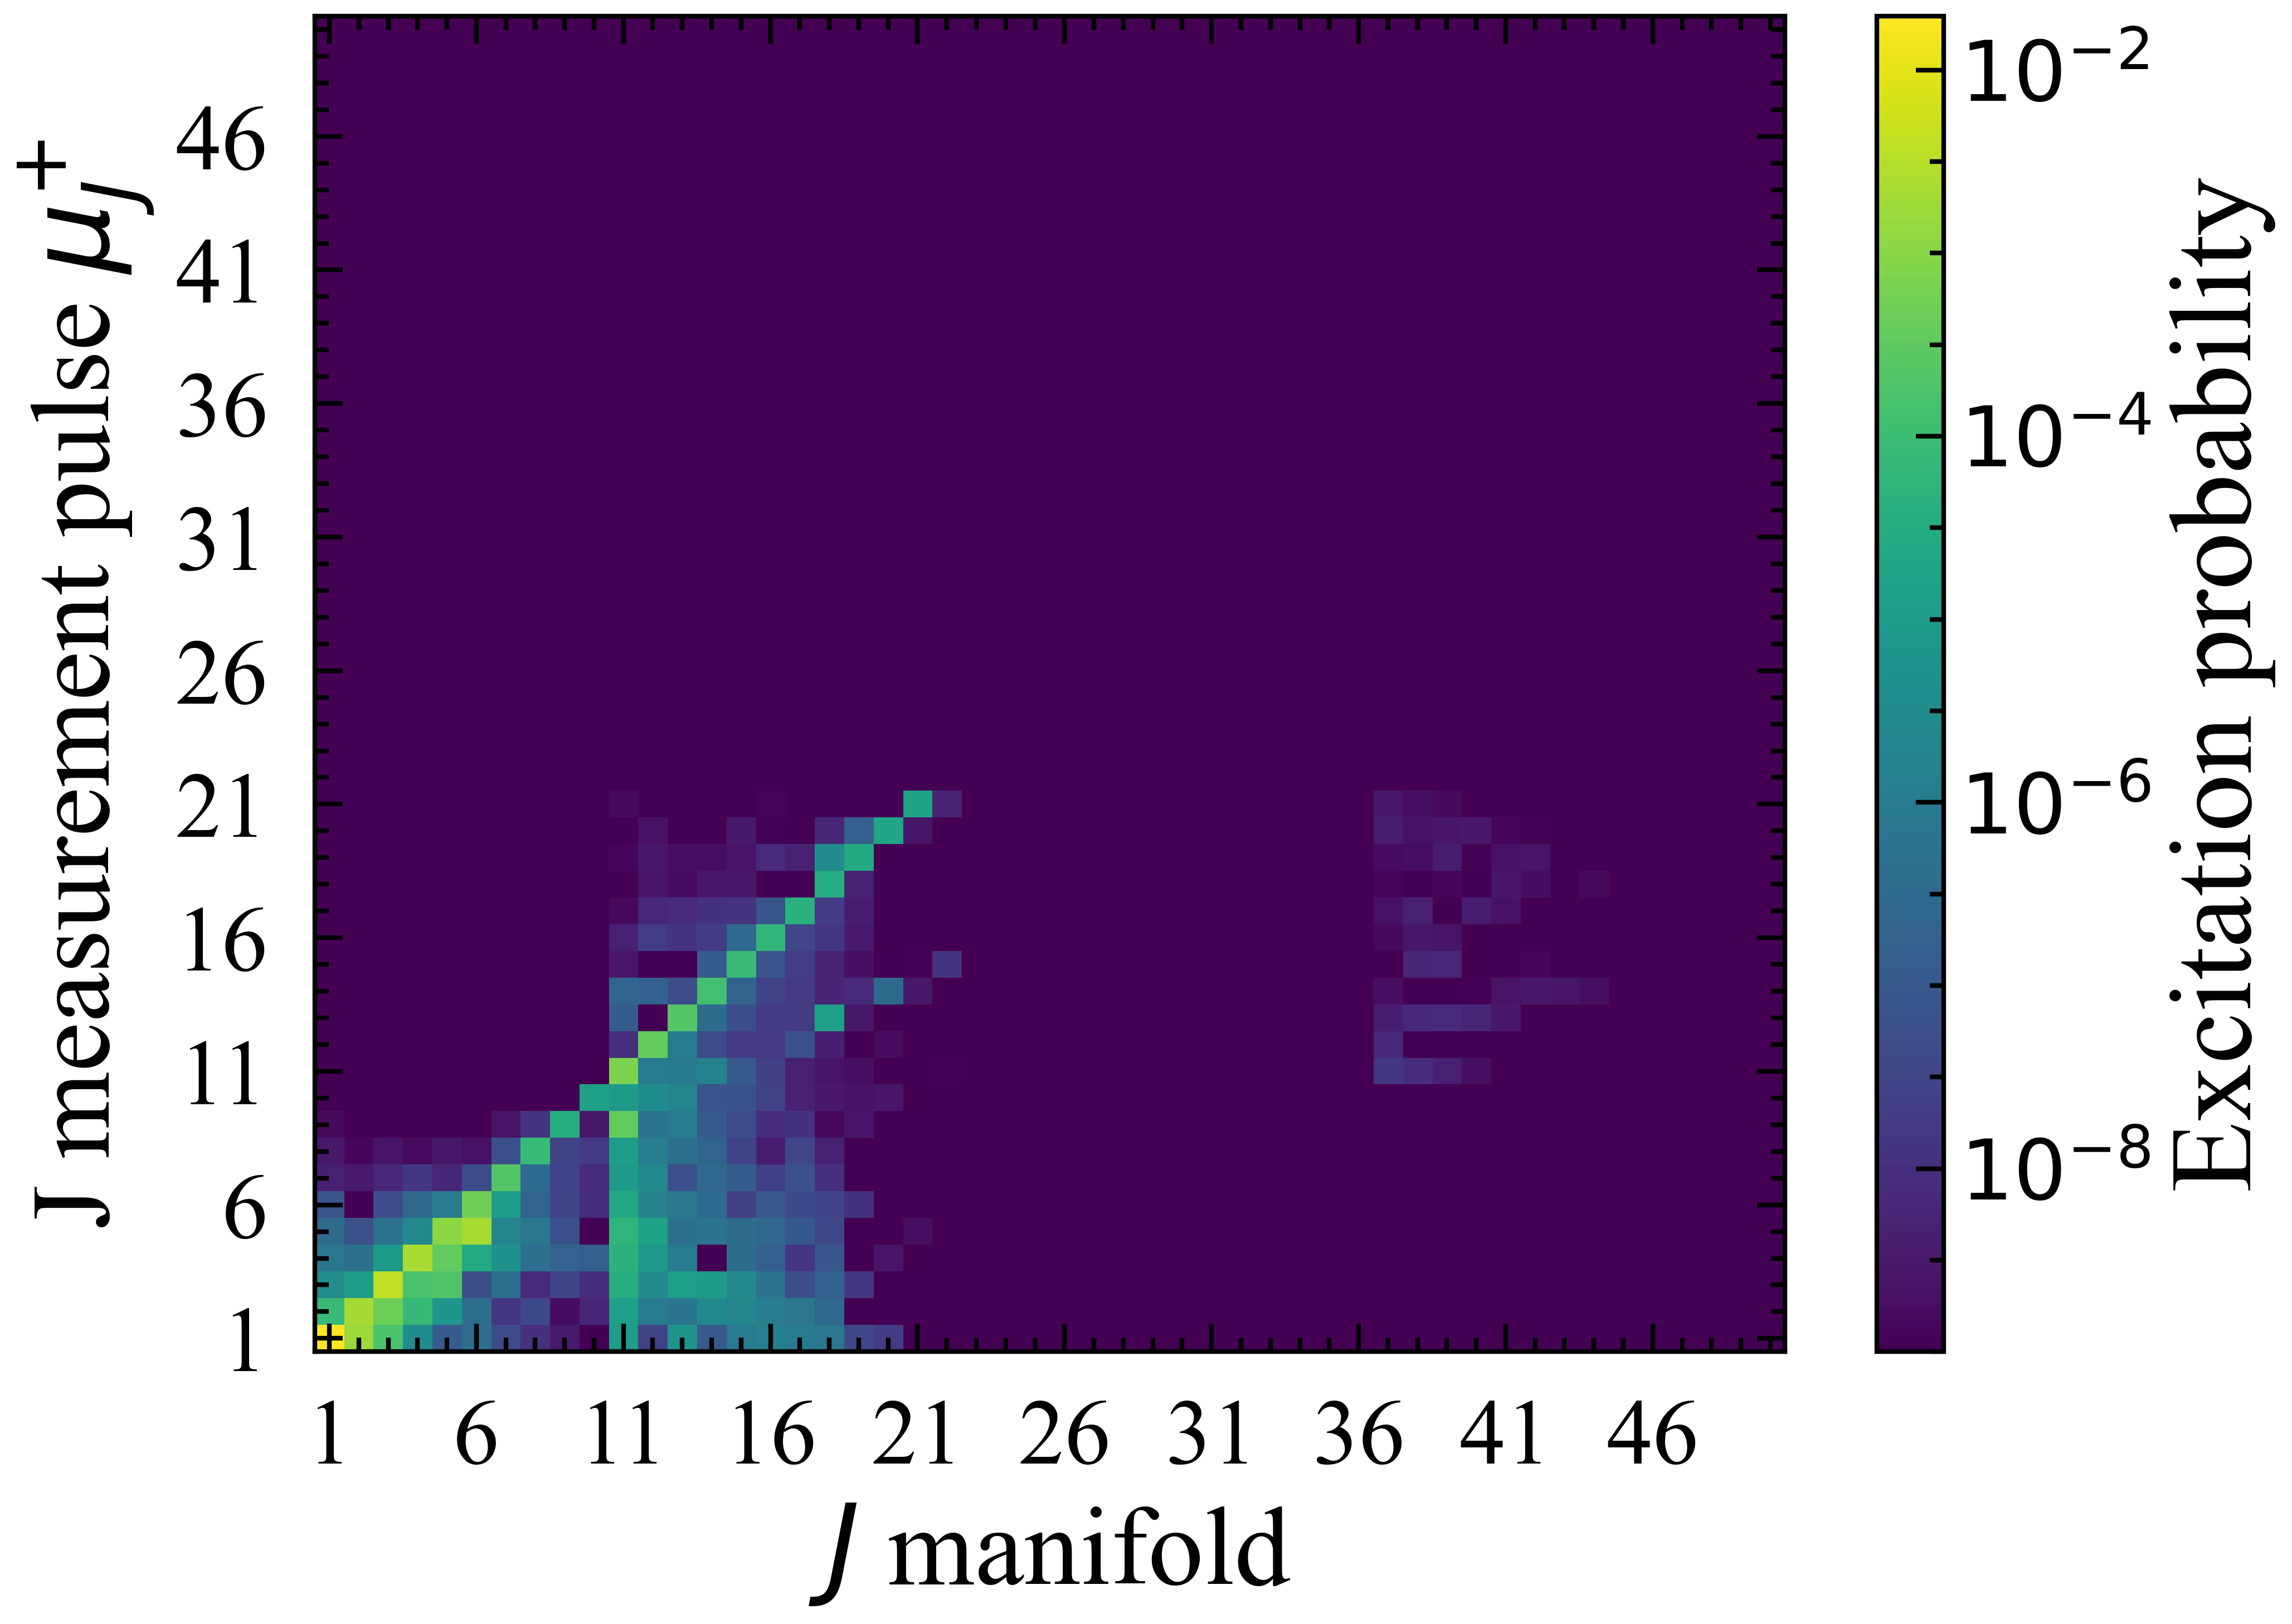

In [5]:
folder = Path.cwd() / "caoh_init_LM"
folder.mkdir(exist_ok=True)

meas_range = range(1, 51)
manifold_range = range(1, 51)

index = 2
is_minus = False
is_log = True  

heatmap = off_resonant(meas_range, 
                       manifold_range, 
                       folder, 
                       index, 
                       is_minus, 
                       is_log, 
                       figname="off_caoh_init0_log.svg")

### Initialization in the penultimate upper states, with J-dependent Rabi rate

The off-resonant coupling to $| J;m+5/2;- \rangle$ is analyzed.

Saved figure in: /home/stripzio/bayesian-qls/re_project/images/off_caoh_init1.svg


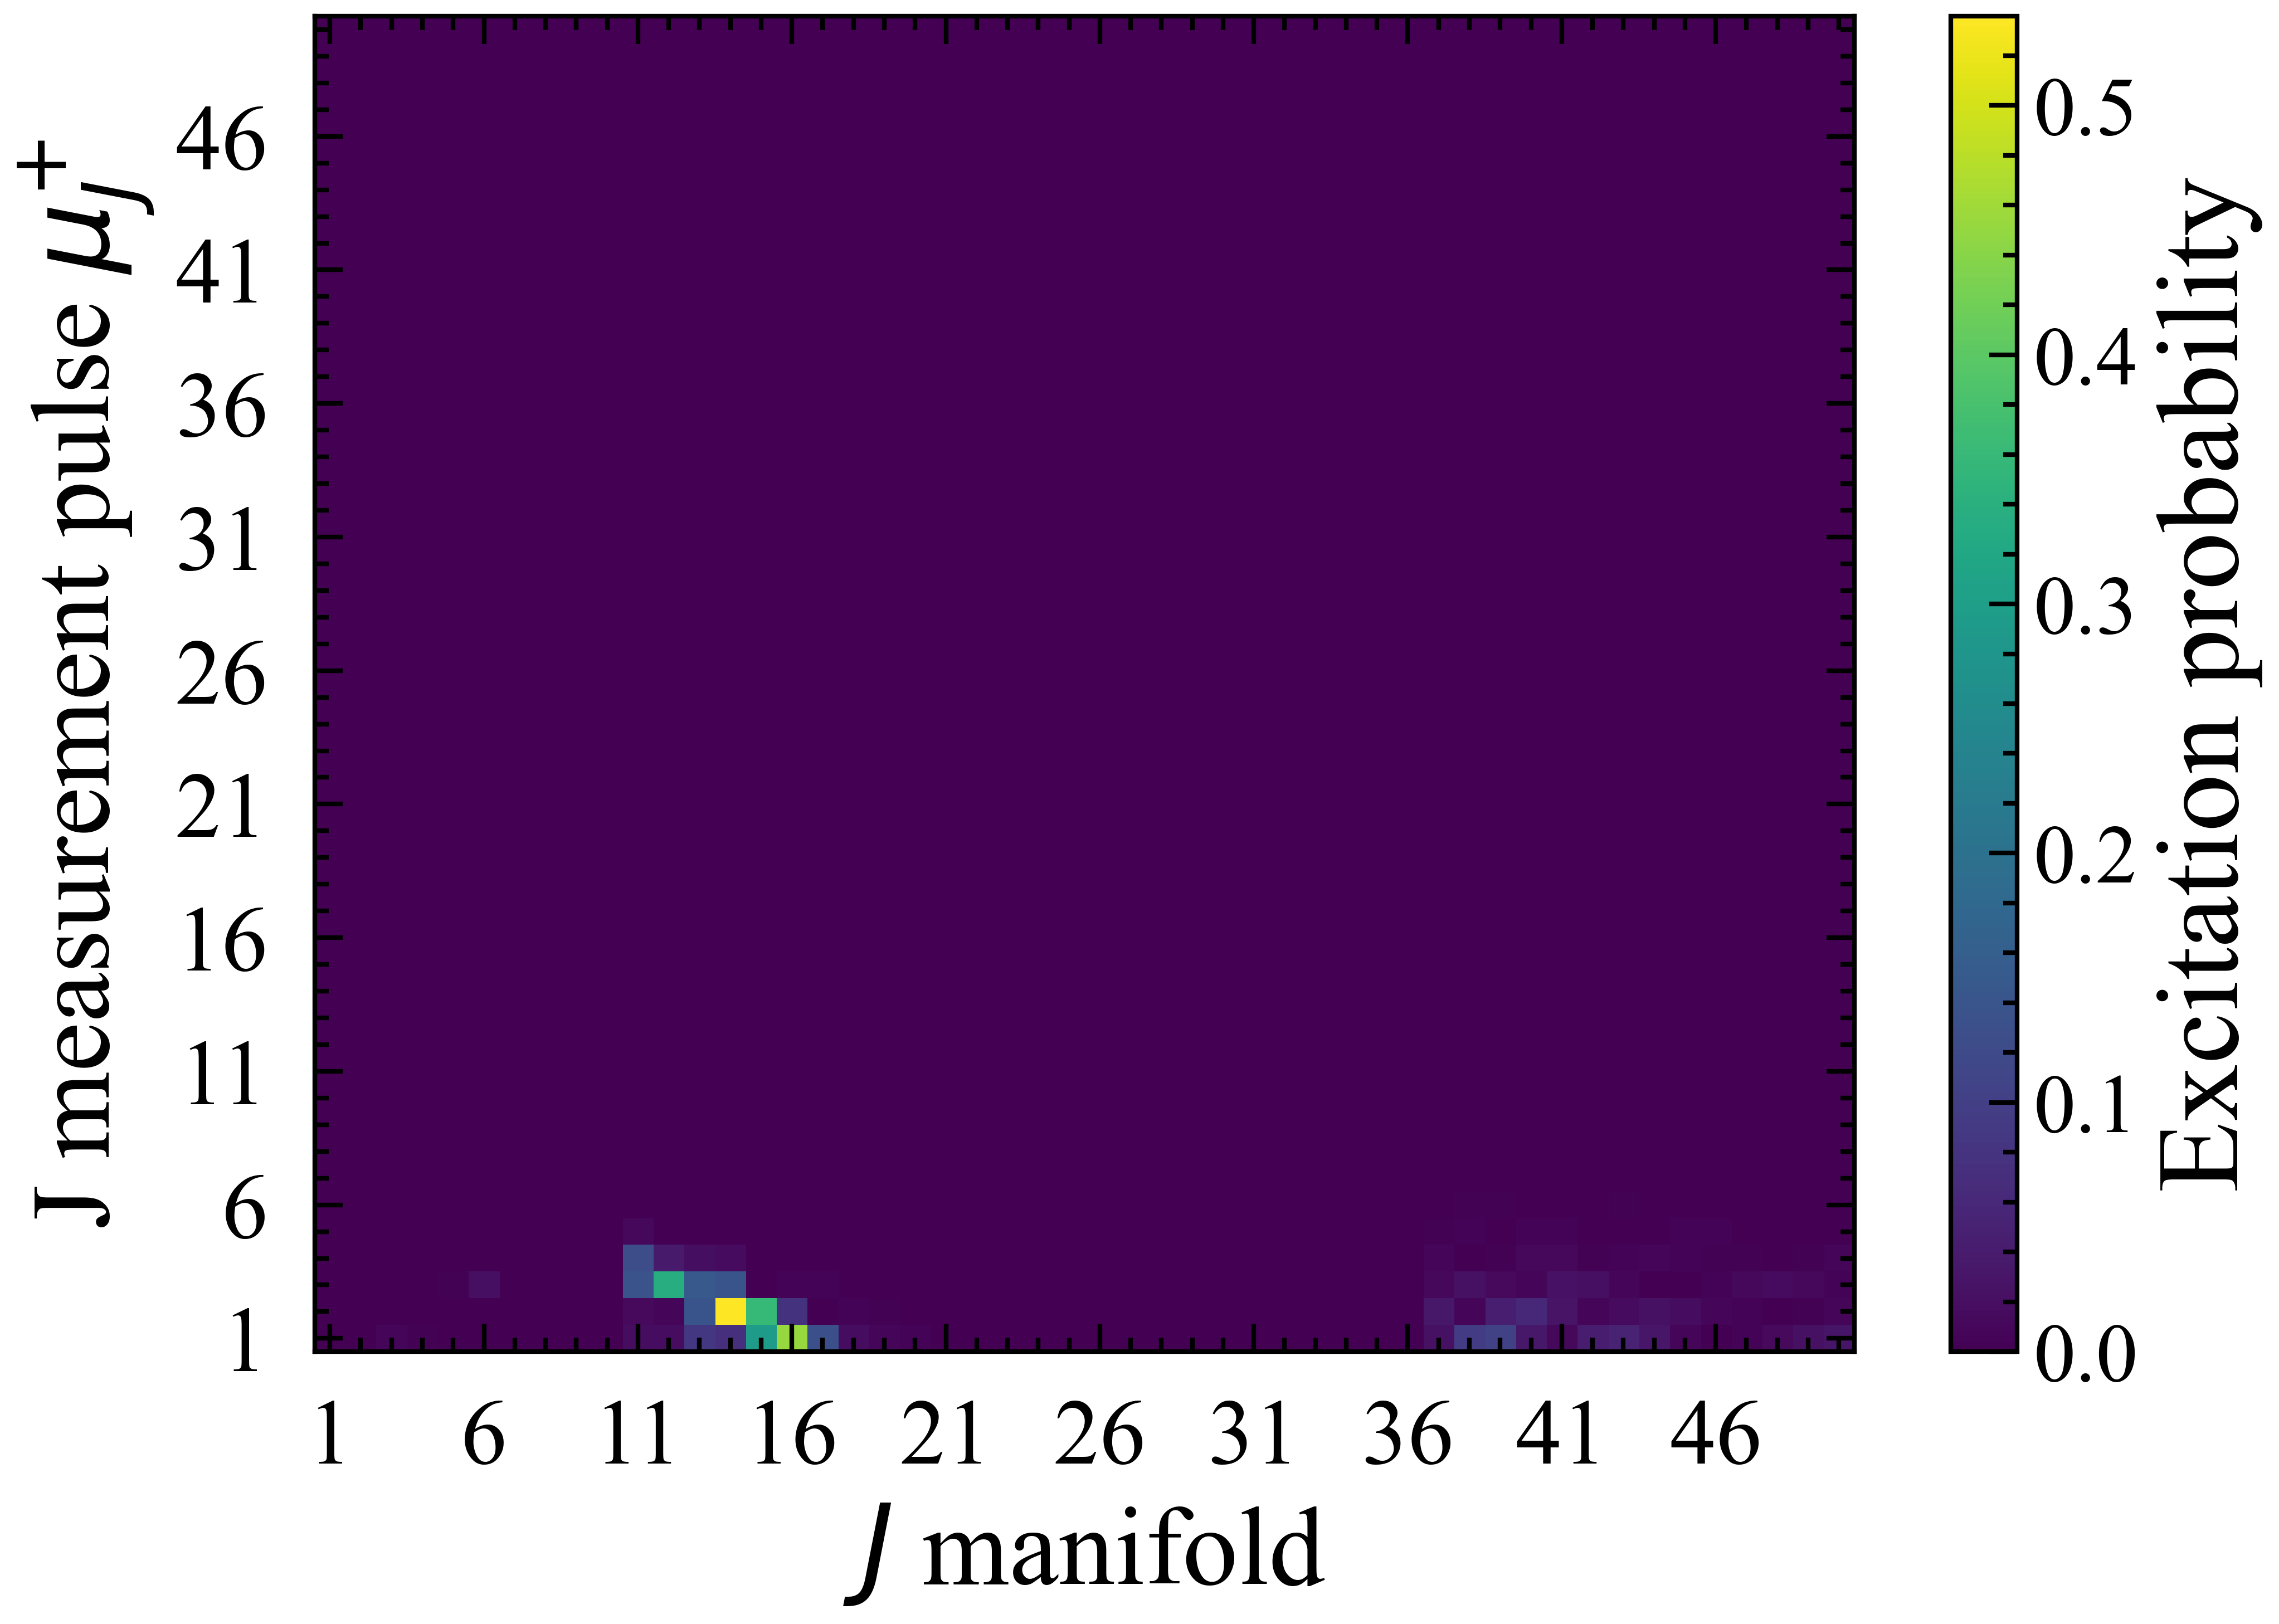

In [9]:
folder = Path.cwd() / "caoh_init_PU"
folder.mkdir(exist_ok=True)

meas_range = range(1, 51)
manifold_range = range(1, 51)

index = 3
is_minus = False
is_log = False  

heatmap = off_resonant(meas_range, 
                       manifold_range, 
                       folder, 
                       index, 
                       is_minus, 
                       is_log, 
                       figname="off_caoh_init1.svg")

# CaH

### Initialization in the leftmost states, with constant Rabi rate

The off-resonant coupling to $| J;m+3/2;- \rangle$ is analyzed.

/tmp/ipykernel_116177/2660554865.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"$10^{{{int(t)}}}$" for t in ticks])


Saved figure in: /home/stripzio/bayesian-qls/re_project/images/off_cah_init0_log.svg


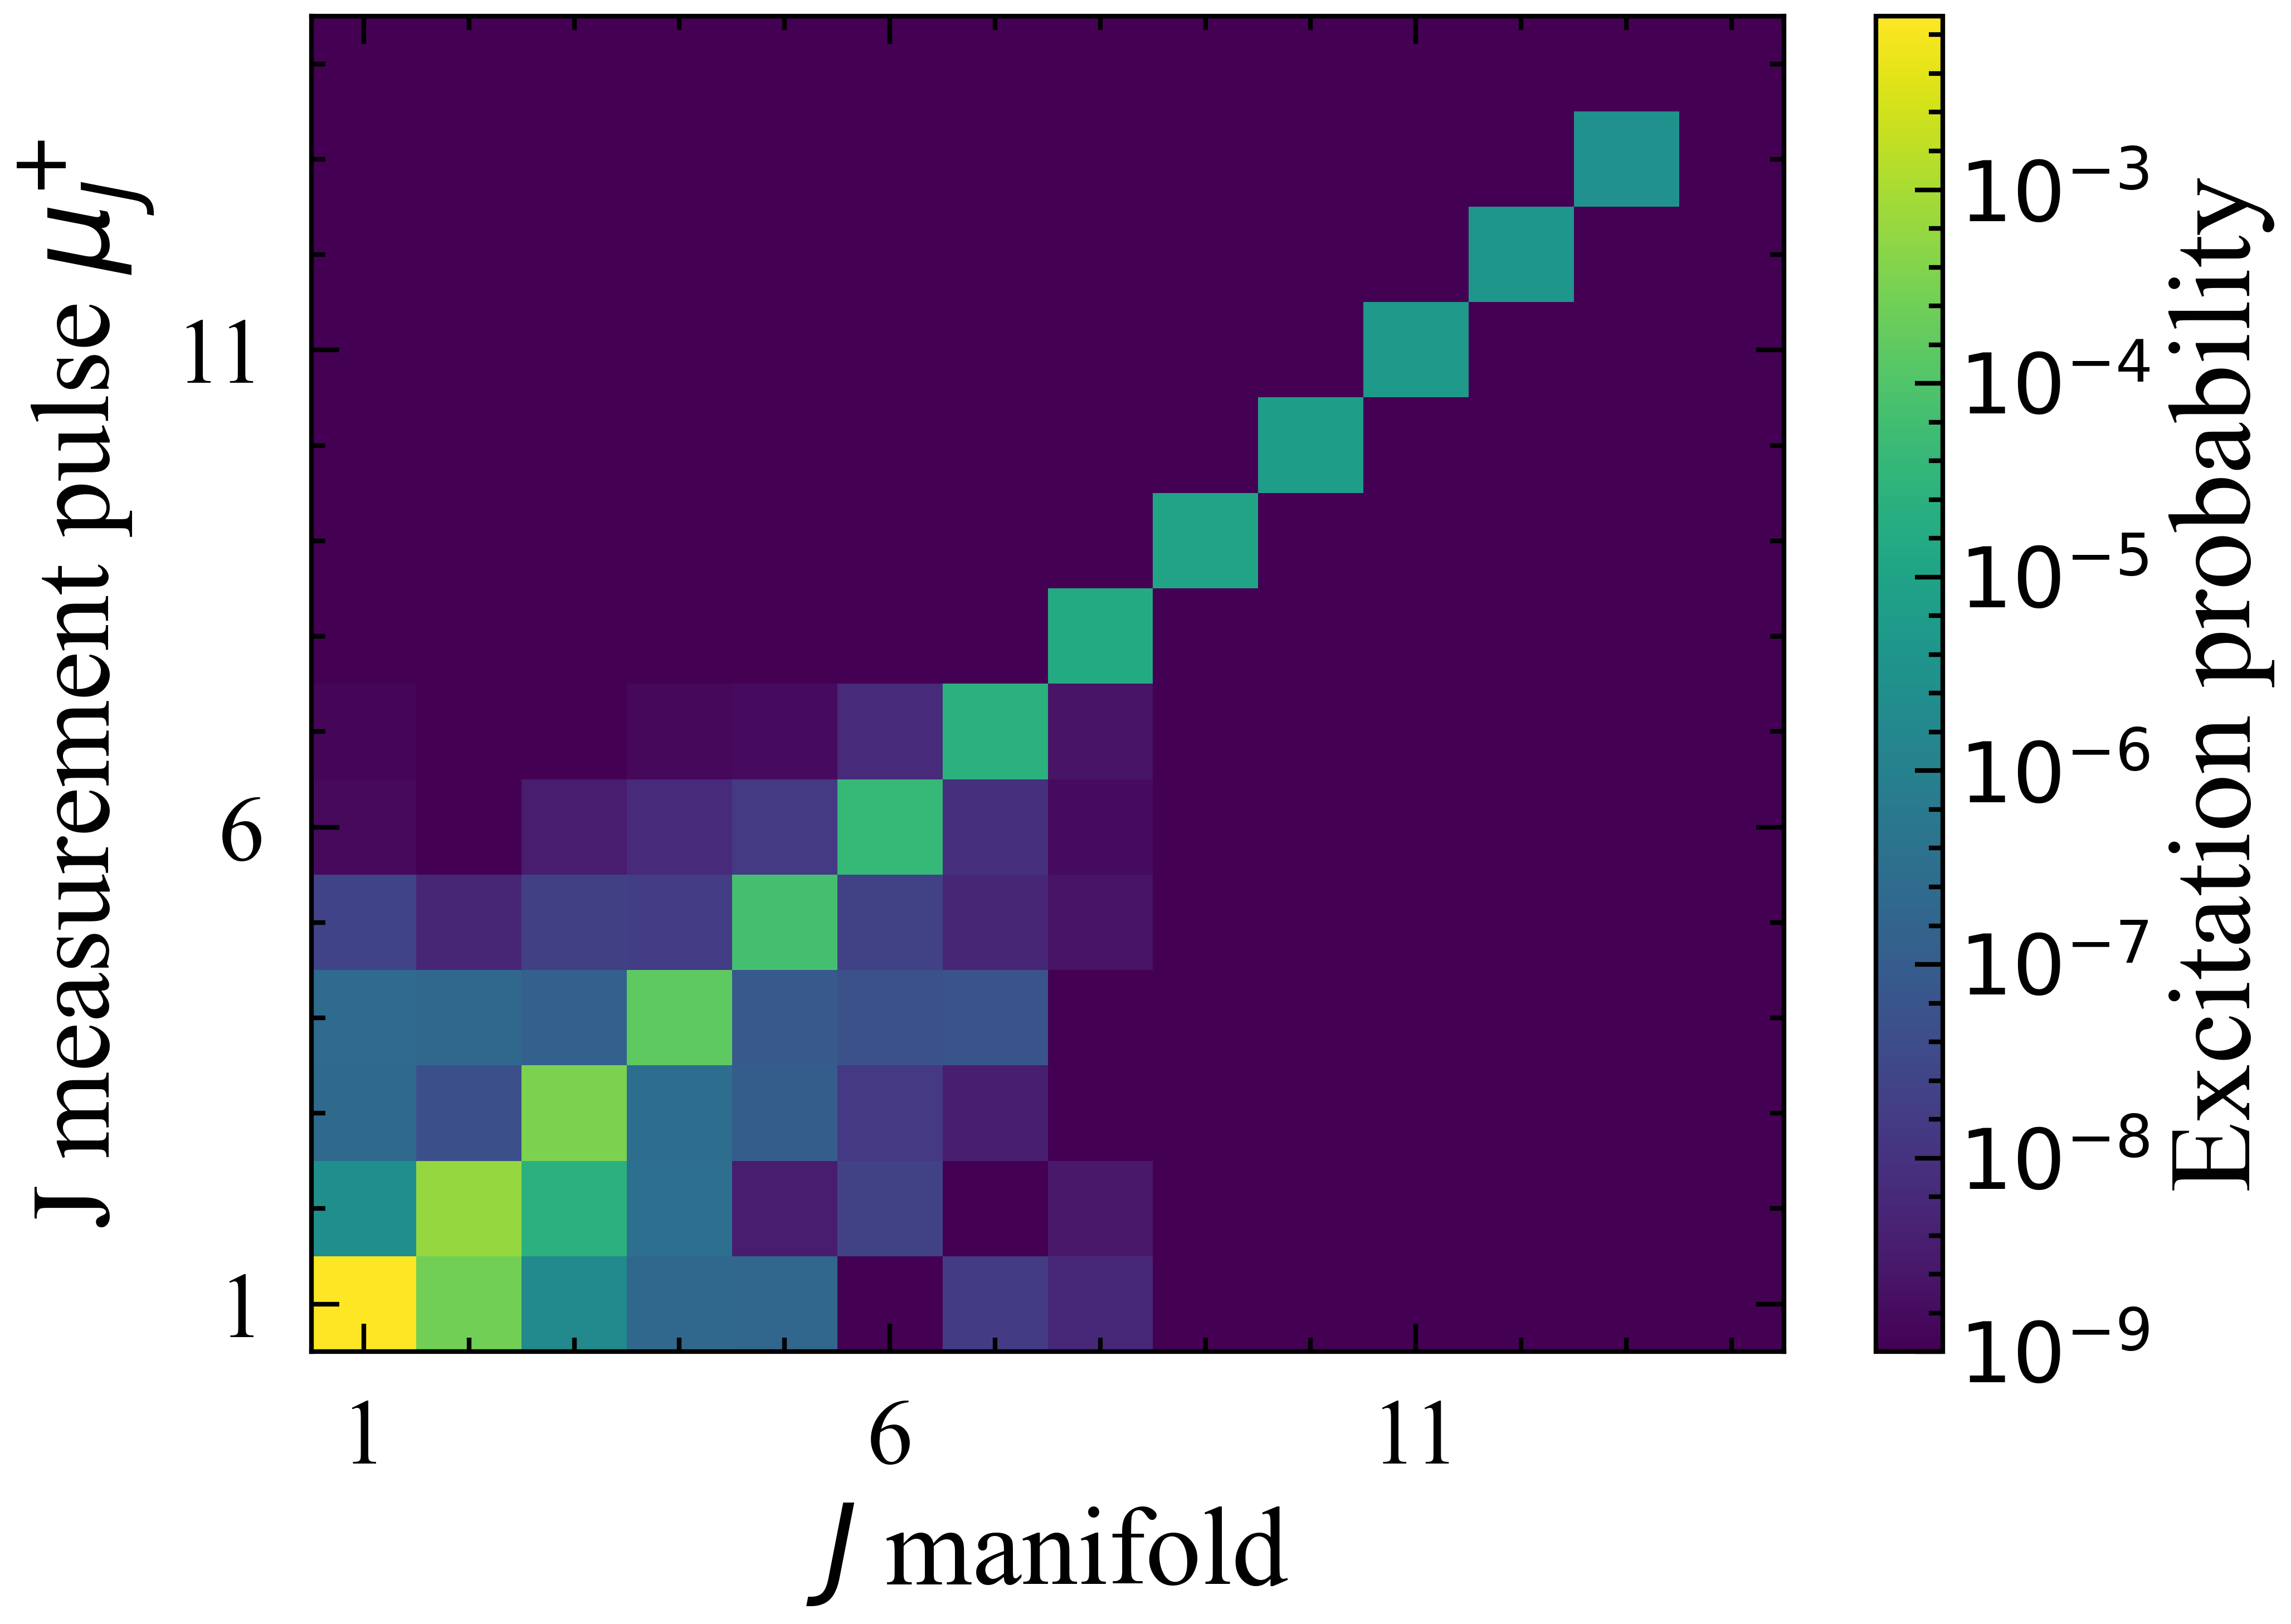

In [8]:
folder = Path.cwd() / "cah_init_LM"
folder.mkdir(exist_ok=True)

meas_range = range(1, 15)
manifold_range = range(1, 15)

index = 2
is_minus = False
is_log = True  

heatmap = off_resonant(meas_range, 
                       manifold_range, 
                       folder, 
                       index, 
                       is_minus, 
                       is_log, 
                       figname="off_cah_init0_log.svg")

### Initialization in the penultimate upper states, with constant Rabi rate

The off-resonant coupling to $| J;m+5/2;- \rangle$ is analyzed.

/tmp/ipykernel_116177/2660554865.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([f"$10^{{{int(t)}}}$" for t in ticks])


Saved figure in: /home/stripzio/bayesian-qls/re_project/images/off_cah_init1_log.svg


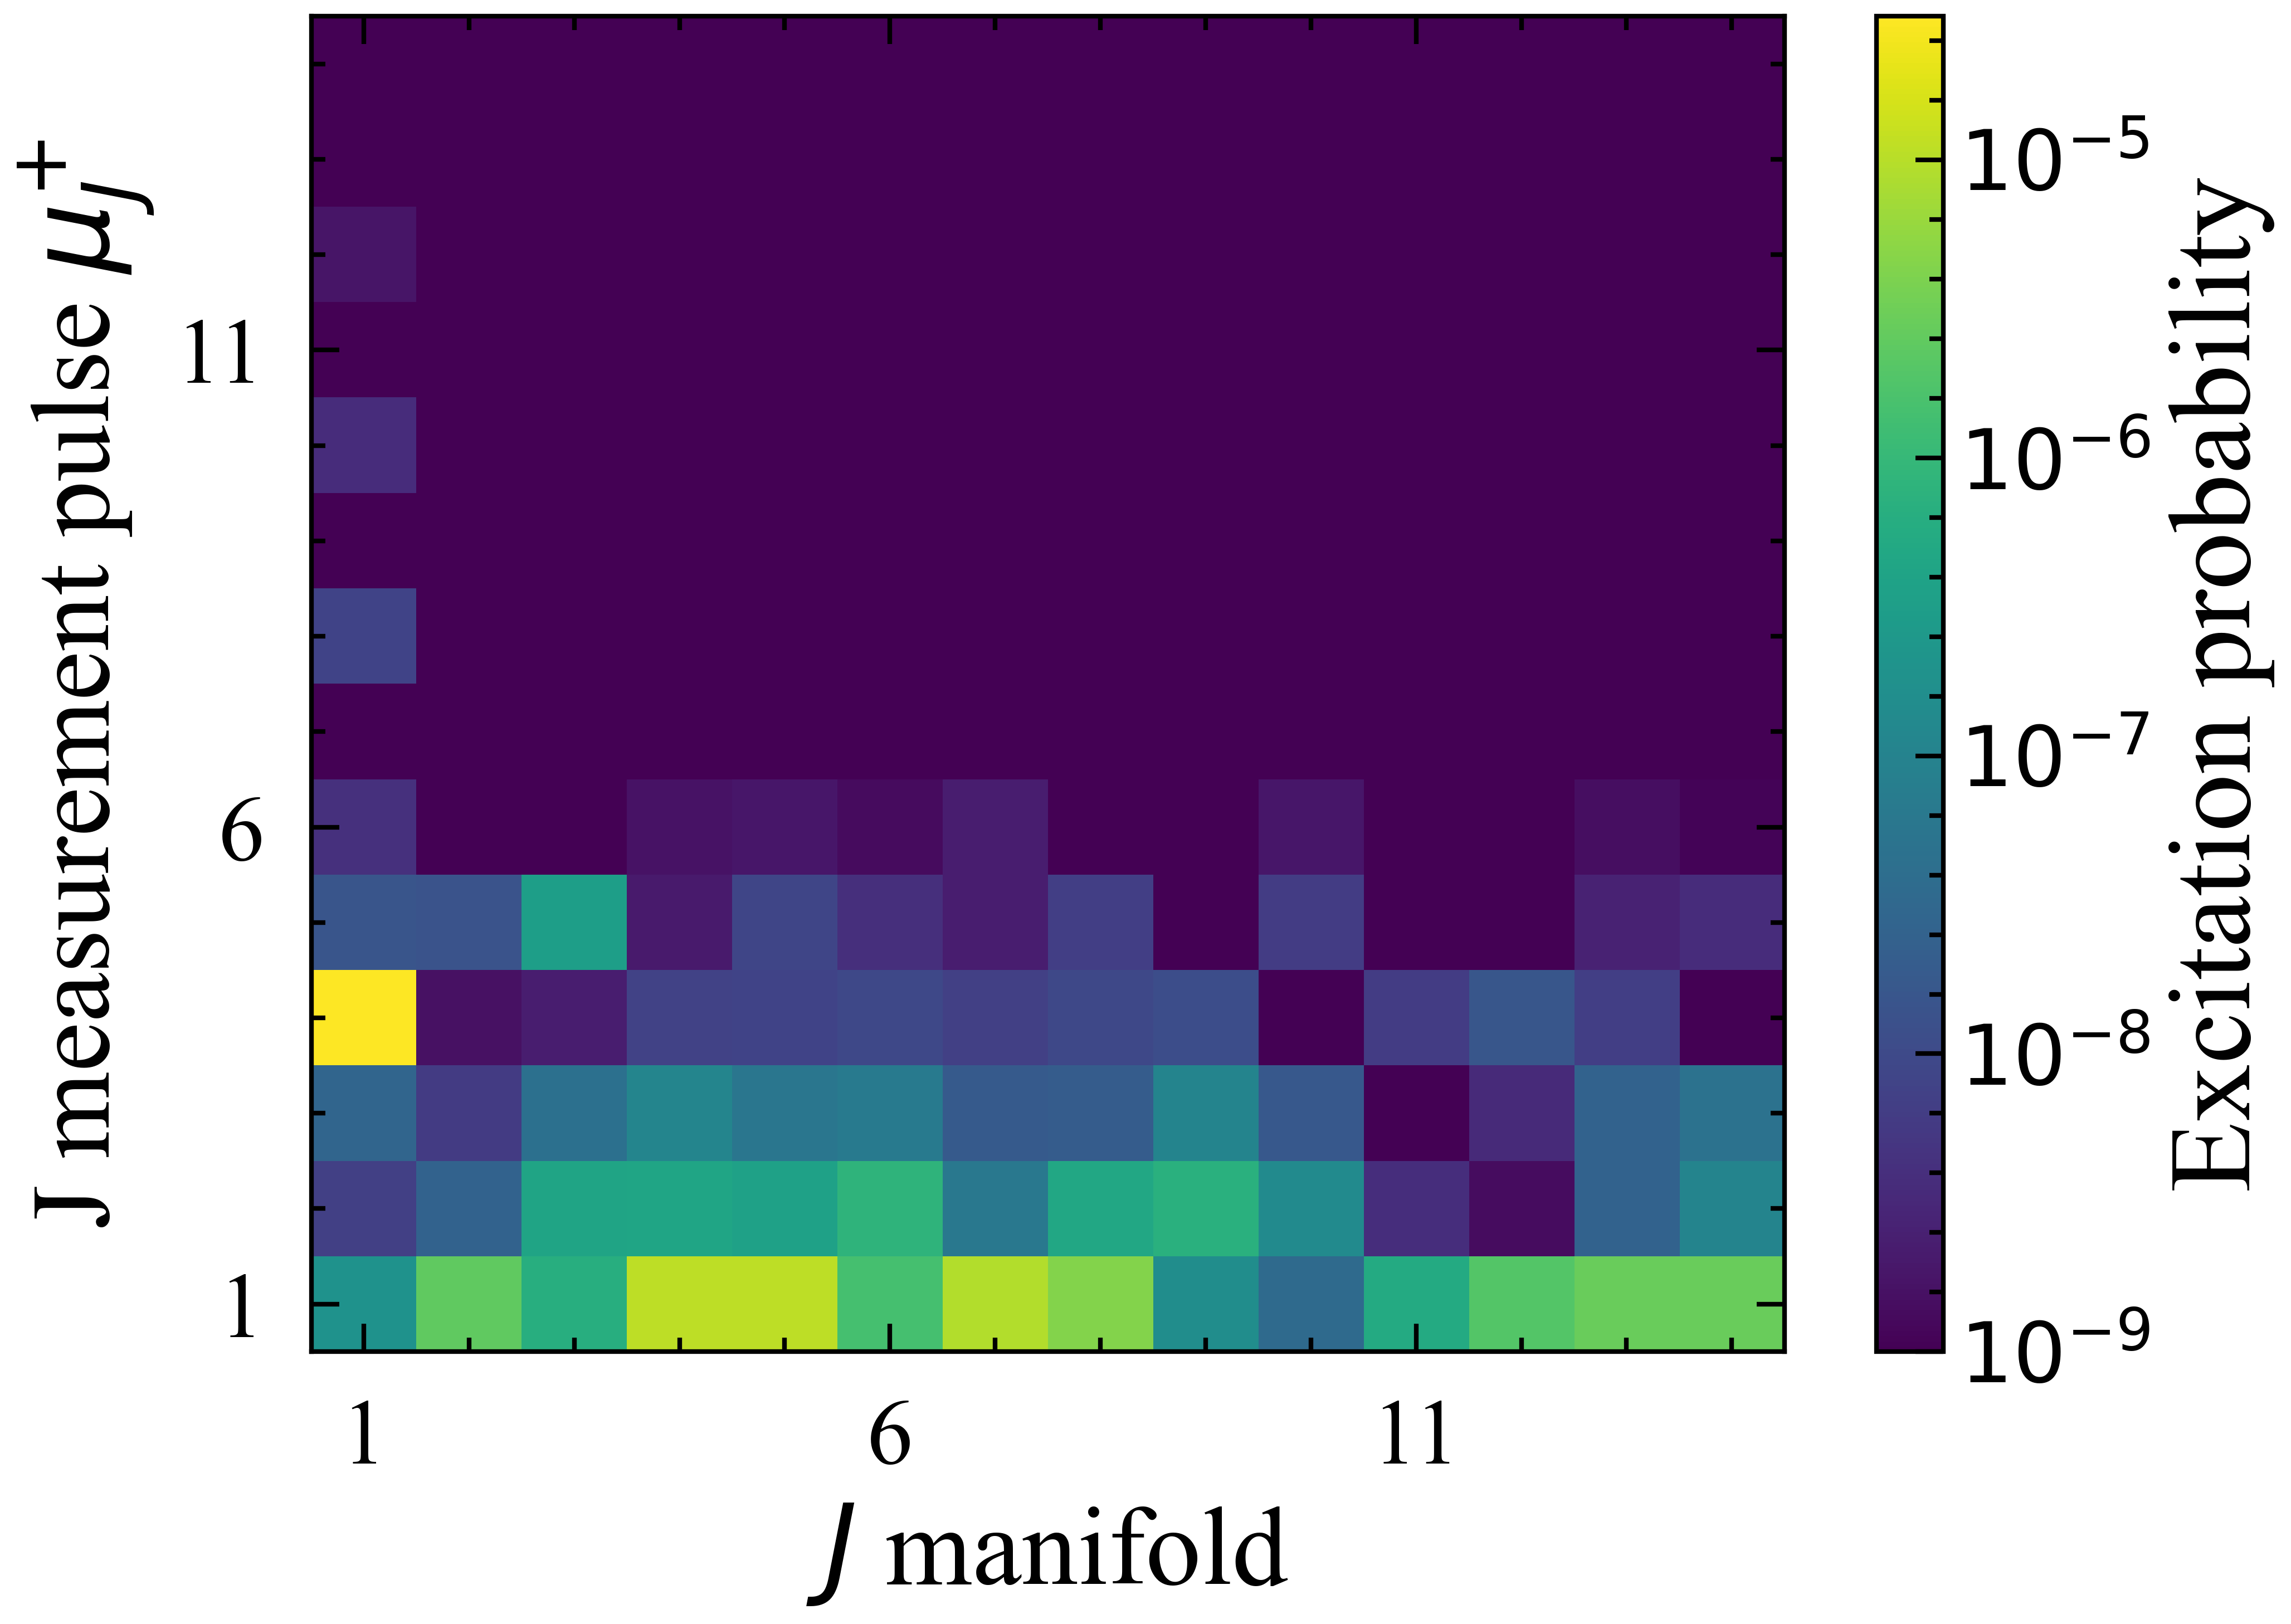

In [11]:
folder = Path.cwd() / "cah_init_PU"
folder.mkdir(exist_ok=True)

meas_range = range(1, 15)
manifold_range = range(1, 15)

index = 3
is_minus = False
is_log = True  

heatmap = off_resonant(meas_range, 
                       manifold_range, 
                       folder, 
                       index, 
                       is_minus, 
                       is_log, 
                       figname="off_cah_init1_log.svg")